# How to Build Passing Networks   

**Competition Focus:** La Liga - 2015/16 Season  
**Dataset:** StatsBomb Open Data (free event data repository)  
**Purpose:** Build passing network visualisations that reveal team structure and playing style, using event data to analyse interactions between players and how possession is organised on the pitch.  
**Methods:** Feature engineering, network construction, spatial alignment across matches, and aggregation of player interactions into a season-level network.  
**Author:** [Victoria Friss de Kereki](https://www.linkedin.com/in/victoria-friss-de-kereki/)  
**Medium Articles:**  
_Coming soon_

**Notebook first written:** `13/05/2026`  
**Last updated:** `13/05/2026`  

> This notebook presents a step-by-step approach to building passing networks using event data from the 2015/16 La Liga season. Passes between players are aggregated to construct networks where nodes represent players’ average on-ball positions and edges reflect passing interactions.  
>
> To ensure consistency across matches, player positions are spatially aligned before aggregation, allowing a stable representation of team structure despite rotations and tactical variation.  
>
> Match-level networks are combined into a single season-level network, where node positions reflect average spatial roles and edges capture overall passing tendencies across the season.  
>
> The objective is not to evaluate performance, but to demonstrate how network-based visualisation techniques can be used to better understand and communicate patterns in football data.  

---------------------

## 1. Packages and Configuration

In [1]:
# Standard library
import math
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# Football data||
from statsbombpy import sb

# Machine learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Utilities
from tqdm import tqdm

warnings.filterwarnings("ignore", message="credentials were not supplied")

## Check Bundesliga

In [2]:
import pandas as pd
from statsbombpy import sb

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# ------------------------------------------------------------
# 1. LOAD ALL COMPETITIONS
# ------------------------------------------------------------
free_comps = sb.competitions()

# Keep only men's competitions
comps = free_comps[
    free_comps["competition_gender"] == "male"
].copy()

# Extract season start year
comps["season_start"] = (
    comps["season_name"]
    .str.split("/")
    .str[0]
    .astype(int)
)

# Keep only seasons >= 2015
comps = comps[comps["season_start"] >= 2015].copy()


# ------------------------------------------------------------
# 2. COUNT MATCHES PER COMPETITION + SEASON
# ------------------------------------------------------------
match_counts = []

for comp_id, season_id in zip(comps["competition_id"], comps["season_id"]):
    
    try:
        matches = sb.matches(competition_id=comp_id, season_id=season_id)
        matches_count = len(matches)
    except:
        matches_count = 0

    match_counts.append({
        "competition_id": comp_id,
        "season_id": season_id,
        "matches_count": matches_count
    })

match_counts_df = pd.DataFrame(match_counts)


# ------------------------------------------------------------
# 3. MERGE METADATA
# ------------------------------------------------------------
metadata_cols = [
    "competition_id",
    "season_id",
    "competition_name",
    "season_name",
    "country_name"
]

match_counts_df = match_counts_df.merge(
    comps[metadata_cols],
    on=["competition_id", "season_id"],
    how="left"
)


# ------------------------------------------------------------
# 4. KEEP "FULL" DATASETS ONLY
# (threshold: tweak if needed)
# ------------------------------------------------------------
FULL_MATCH_THRESHOLD = 100  # leagues ~300+, cups smaller

full_comps = match_counts_df[
    match_counts_df["matches_count"] >= FULL_MATCH_THRESHOLD
].copy()


# ------------------------------------------------------------
# 5. SORT & VIEW
# ------------------------------------------------------------
full_comps = full_comps.sort_values(
    "matches_count",
    ascending=False
).reset_index(drop=True)

full_comps

,competition_id,season_id,matches_count,competition_name,season_name,country_name
0,11,27,380,La Liga,2015/2016,Spain
1,2,27,380,Premier League,2015/2016,England
2,12,27,380,Serie A,2015/2016,Italy
3,7,27,377,Ligue 1,2015/2016,France
4,9,27,306,1. Bundesliga,2015/2016,Germany
5,1238,108,115,Indian Super league,2021/2022,India


## 2. Load Competition, Match & Event Data

In [3]:
comp = 9
season = 27

# Download Matches
matches_df = sb.matches(
    competition_id=comp,
    season_id=season
)

len(matches_df)

306

In [4]:
matches_df.head()

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3890561,2016-05-14,15:30:00.000,Germany - 1. Bundesliga,2015/2016,Hoffenheim,Schalke 04,1,4,available,unscheduled,2023-07-24T07:47:12.510532,None,34,Regular Season,PreZero Arena,Felix Brych,Julian Nagelsmann,André Breitenreiter,1.1.0,2,2
1,3890505,2016-04-02,15:30:00.000,Germany - 1. Bundesliga,2015/2016,Bayern Munich,Eintracht Frankfurt,1,0,available,unscheduled,2023-08-03T13:14:14.503553,None,28,Regular Season,Allianz Arena,Florian Meyer,Josep Guardiola i Sala,Niko Kovač,1.1.0,2,2
2,3890511,2016-04-08,20:30:00.000,Germany - 1. Bundesliga,2015/2016,Hertha Berlin,Hannover 96,2,2,available,unscheduled,2023-08-06T05:50:38.345688,None,29,Regular Season,Olympiastadion Berlin,Benjamin Brand,Pál Dárdai,Daniel Stendel,1.1.0,2,2
3,3890515,2016-04-09,15:30:00.000,Germany - 1. Bundesliga,2015/2016,Hamburger SV,Darmstadt 98,1,2,available,unscheduled,2023-07-18T17:52:17.363623,None,29,Regular Season,Volksparkstadion,Peter Sippel,Bruno Labbadia,Dirk Schuster,1.1.0,2,2
4,3890411,2015-12-20,16:30:00.000,Germany - 1. Bundesliga,2015/2016,Hertha Berlin,FSV Mainz 05,2,0,available,unscheduled,2023-07-16T13:47:06.565811,None,17,Regular Season,Olympiastadion Berlin,Peter Sippel,Pál Dárdai,Martin Schmidt,1.1.0,2,2


In [5]:
from tqdm import tqdm
import pandas as pd
from statsbombpy import sb

all_passes = []

for match_id in tqdm(matches_df["match_id"], desc="Extracting passes"):
    
    events = sb.events(match_id=match_id)
    
    passes = events[events["type"] == "Pass"].copy()
    passes["match_id"] = match_id
    
    all_passes.append(passes)

passes_df = pd.concat(all_passes, ignore_index=True)

Extracting passes: 100%|██████████| 306/306 [08:07<00:00,  1.59s/it]


In [6]:
matches_meta = matches_df[[
    "match_id",
    "match_date",
    "season",
    "competition",
    "home_team",
    "away_team",
    "home_score",
    "away_score"
]].copy()

passes_df = passes_df.merge(matches_meta, on="match_id", how="left")

In [7]:
len(passes_df)

295599

In [8]:
passes_df.to_csv("Datasets/passes_bundesliga_201516_statsbomb_all.csv", index=False)

In [2]:
import pandas as pd
import ast

passes_df = pd.read_csv(
    "Datasets/passes_bundesliga_201516_statsbomb_all.csv",
    converters={
        "location": lambda x: ast.literal_eval(x) if pd.notna(x) else None,
        "pass_end_location": lambda x: ast.literal_eval(x) if pd.notna(x) else None
    }
)

C:\Users\vicky\AppData\Local\Temp\ipykernel_31528\3687868732.py:4: DtypeWarning: Columns (33,40,91,92,99) have mixed types. Specify dtype option on import or set low_memory=False.
  passes_df = pd.read_csv(


## 3. Data Cleaning & Feature Engineering

In [3]:
# If working with data I

passes = passes_df.copy()

def extract_coords(col):
    x = col.apply(lambda v: v[0] if isinstance(v, (list, tuple)) else None)
    y = col.apply(lambda v: v[1] if isinstance(v, (list, tuple)) else None)
    return x, y

passes["start_x"], passes["start_y"] = extract_coords(passes["location"])
passes["end_x"], passes["end_y"] = extract_coords(passes["pass_end_location"])

FEATURES = ["start_x", "start_y", "end_x", "end_y"]

# Remove unwanted passes
passes = passes[passes["pass_outcome"] != "Injury Clearance"].copy()

# Fix pitch bounds

for col, max_val in [("start_x", 120), ("end_x", 120), ("start_y", 80), ("end_y", 80)]:
    passes[col] = passes[col].clip(lower=0, upper=max_val)

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None )

passes.head()

,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,50_50,bad_behaviour_card,ball_recovery_offensive,injury_stoppage_in_chain,miscontrol_aerial_won,pass_no_touch,pass_straight,block_offensive,foul_committed_type,foul_committed_offensive,shot_deflected,clearance_other,goalkeeper_success_out,pass_miscommunication,dribble_no_touch,foul_committed_penalty,foul_won_penalty,shot_open_goal,block_save_block,goalkeeper_punched_out,shot_redirect,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_shot_saved_to_post,shot_saved_to_post,goalkeeper_lost_out,goalkeeper_success_in_play,shot_follows_dribble,half_start_late_video_start,match_date,season,competition,home_team,away_team,home_score,away_score,start_x,start_y,end_x,end_y
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.453238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,644e16d7-10ca-45f0-8128-fc0055d6f753,5,NaN,"[61.0, 40.1]",3890561,0,NaN,NaN,NaN,-1.919567,NaN,Left Foot,NaN,NaN,NaN,"[60.2, 37.9]",NaN,Ground Pass,NaN,2.340940,NaN,NaN,Andrej Kramarić,5460.0,NaN,NaN,NaN,NaN,Kick Off,1,From Kick Off,Mark Uth,8387.0,Right Attacking Midfield,2,Hoffenheim,175,['7602c8d9-d988-4eae-bb9f-309fbad4c7c5'],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hoffenheim,175,00:00:00.482,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-05-14,2015/2016,Germany - 1. Bundesliga,Hoffenheim,Schalke 04,1,4,61.0,40.1,60.2,37.9
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.151865,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77e2ddaf-6de3-49e7-a318-7d765799b543,8,NaN,"[59.4, 38.3]",3890561,0,NaN,NaN,NaN,2.536994,NaN,Left Foot,NaN,NaN,NaN,"[53.9, 42.1]",NaN,Ground Pass,NaN,6.685058,NaN,NaN,Sebastian Rudy,6039.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Andrej Kramarić,5460.0,Center Forward,2,Hoffenheim,175,['69e3b0a7-5847-40db-91d5-0e24fb150f63'],1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hoffenheim,175,00:00:01.015,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-05-14,2015/2016,Germany - 1. Bundesliga,Hoffenheim,Schalke 04,1,4,59.4,38.3,53.9,42.1
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.389406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2c51f271-c812-45af-896b-06f49a14a5bb,11,NaN,"[52.3, 45.2]",3890561,0,NaN,NaN,NaN,2.390664,NaN,Right Foot,NaN,NaN,NaN,"[34.3, 62.0]",NaN,Ground Pass,NaN,24.621940,NaN,NaN,Fabian Lukas Schär,5537.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Sebastian Rudy,6039.0,Left Defensive Midfield,2,Hoffenheim,175,['c30d7035-bb00-4012-9b06-2f3135cdf4d6'],2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hoffe

# Passing Networks

## Unified version

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from scipy.optimize import linear_sum_assignment


# ============================================================
# HELPER
# ============================================================
def norm(x):
    if pd.isna(x):
        return None
    return str(x).strip().lower()


# ============================================================
# STARTING XI (ORDERED BY TIME)
# ============================================================
def get_starting_xi(match_id, team, sb):

    try:
        lineup = sb.lineups(match_id=match_id)[team]
    except Exception:
        return None

    df = lineup.explode("positions")
    pos = pd.json_normalize(df["positions"])

    df = pd.concat(
        [df.drop(columns="positions").reset_index(drop=True), pos],
        axis=1
    )

    df["player"] = df["player_name"].apply(norm)
    df["nickname"] = df["player_nickname"]

    df["from"] = df["from"].fillna("0:00")
    df = df.sort_values("from")

    starters = df.head(11).copy()

    if len(starters) < 7:
        return None

    return starters[["player", "nickname"]]


# ============================================================
# MATCH NETWORK (WITH SUBSTITUTES SUPPORT)
# ============================================================
def build_match_network(match_id, team, passes, sb):

    df = passes[(passes["match_id"] == match_id) & (passes["team"] == team)].copy()

    if df.empty:
        return None

    df["p"] = df["player"].apply(norm)
    df["r"] = df["pass_recipient"].apply(norm)

    xi = get_starting_xi(match_id, team, sb)
    if xi is None:
        return None

    starters = xi["player"].tolist()

    # -------------------------
    # PLAYER LOCATIONS (ALL PLAYERS)
    # -------------------------
    start = df[["p", "start_x", "start_y"]].rename(
        columns={"p": "player", "start_x": "x", "start_y": "y"}
    )

    end = df[["r", "end_x", "end_y"]].rename(
        columns={"r": "player", "end_x": "x", "end_y": "y"}
    )

    locs = pd.concat([start, end])

    avg = locs.groupby("player").agg(
        x=("x", "mean"),
        y=("y", "mean")
    ).reset_index()

    # -------------------------
    # KEEP MAIN PLAYERS ONLY (but allow subs)
    # -------------------------
    main_players = avg.sort_values(["x", "y"]).head(11)["player"].tolist()
    avg = avg[avg["player"].isin(main_players)]

    if len(avg) < 7:
        return None

    return avg, df, xi


# ============================================================
# SEASON NETWORK (UNCHANGED STYLE)
# ============================================================
def build_season_network(passes, sb, team, season):

    df = passes[(passes["team"] == team) & (passes["season"] == season)]

    if df.empty:
        return None

    match_ids = df["match_id"].dropna().unique()

    match_nodes = []
    match_passes = []
    xi_list = []

    for m in match_ids:

        res = build_match_network(m, team, passes, sb)
        if res is None:
            continue

        nodes, match_df, xi = res

        match_nodes.append(nodes)
        match_passes.append(match_df)
        xi_list.append(xi)

    if len(match_nodes) == 0:
        return None

    # ALIGNMENT
    reference = match_nodes[0].copy()
    reference["slot"] = range(len(reference))

    aligned_nodes = []

    for nodes in match_nodes:

        if len(nodes) < len(reference):
            continue

        cost = np.linalg.norm(
            nodes[["x", "y"]].values[:, None, :] -
            reference[["x", "y"]].values[None, :, :],
            axis=2
        )

        r, c = linear_sum_assignment(cost)

        nodes = nodes.iloc[r].copy()
        nodes["slot"] = c

        aligned_nodes.append(nodes)

    if not aligned_nodes:
        return None

    nodes_df = pd.concat(aligned_nodes, ignore_index=True)

    node_pos = nodes_df.groupby("slot").agg(
        x=("x", "mean"),
        y=("y", "mean")
    ).reset_index()

    # PLAYER ASSIGNMENT
    counts = (
        nodes_df.groupby(["player", "slot"])
        .size()
        .reset_index(name="count")
    )

    players = counts["player"].unique()
    slots = sorted(nodes_df["slot"].unique())

    matrix = np.zeros((len(players), len(slots)))

    for _, r in counts.iterrows():
        i = list(players).index(r["player"])
        j = slots.index(r["slot"])
        matrix[i, j] = r["count"]

    cost = -matrix
    row_ind, col_ind = linear_sum_assignment(cost)

    final_map = {players[i]: slots[j] for i, j in zip(row_ind, col_ind)}
    slot_to_player = {v: k for k, v in final_map.items()}

    node_pos["player"] = node_pos["slot"].map(slot_to_player)
    node_pos["label"] = node_pos["player"]

    # EDGES
    player_to_slot = nodes_df.groupby("player")["slot"].agg(lambda x: x.mode()[0])

    all_passes = pd.concat(match_passes, ignore_index=True)

    all_passes["slot_from"] = all_passes["p"].map(player_to_slot)
    all_passes["slot_to"] = all_passes["r"].map(player_to_slot)

    edges = (
        all_passes.groupby(["slot_from", "slot_to"])
        .size()
        .reset_index(name="weight")
    )

    edges = edges.dropna()
    edges = edges[edges["slot_from"] != edges["slot_to"]]

    edges = edges.merge(node_pos, left_on="slot_from", right_on="slot")
    edges = edges.merge(
        node_pos,
        left_on="slot_to",
        right_on="slot",
        suffixes=("_start", "_end")
    )

    return node_pos, edges

In [13]:
def plot_network(
    passes,
    sb,
    team=None,
    season=None,
    match_id=None,
    match_level=False,
    n_cols=4
):

    # ============================================================
    # NAME FORMATTER (EXACT SAME AS YOUR ORIGINAL)
    # ============================================================
    def format_nickname(name):
        if pd.isna(name):
            return name
        
        words = str(name).split()
        
        if all(w[0].isupper() or w.lower() in ["de", "da", "del", "van", "von"] for w in words):
            return name
        
        def fix_word(w):
            if w.lower() in ["de", "da", "del", "van", "von"]:
                return w.lower()
            return w.capitalize()
        
        return " ".join(fix_word(w) for w in words)


    # ============================================================
    # 1. SINGLE MATCH (BOTH TEAMS) — KEEP YOUR ORIGINAL STYLE
    # ============================================================
    if match_id is not None and not match_level:
        plot_match_two_teams(match_id, passes, sb)
        return


    # ============================================================
    # 2. ALL MATCHES FOR TEAM (GRID) — FIXED STYLE
    # ============================================================
    if match_level and team is not None:

        df = passes[(passes["team"] == team) & (passes["season"] == season)]
        match_ids = df["match_id"].dropna().unique()

        results = []

        for m in match_ids:

            res = build_match_network(m, team, passes, sb)
            if res is None:
                continue

            nodes, match_df, _ = res

            match_df["slot_from"] = match_df["p"]
            match_df["slot_to"] = match_df["r"]

            edges = (
                match_df.groupby(["slot_from", "slot_to"])
                .size()
                .reset_index(name="weight")
            )

            edges = edges[edges["slot_from"] != edges["slot_to"]]

            edges = edges.merge(
                nodes.rename(columns={"player": "slot_from", "x": "x_start", "y": "y_start"}),
                on="slot_from"
            )

            edges = edges.merge(
                nodes.rename(columns={"player": "slot_to", "x": "x_end", "y": "y_end"}),
                on="slot_to"
            )

            # ---- MATCH LABEL (CLEAN) ----
            row = passes[passes["match_id"] == m].iloc[0]
            opponent = row["away_team"] if row["home_team"] == team else row["home_team"]
            score = f"{row['home_score']}–{row['away_score']}"
            date = pd.to_datetime(row["match_date"]).strftime("%d %b")

            title = f"{opponent} ({score})\n{date}"

            results.append((title, nodes, edges))

        if not results:
            print("No valid matches")
            return

        n_rows = int(np.ceil(len(results) / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
        axes = axes.flatten()

        for i, (title, node_pos, links) in enumerate(results):

            pitch = Pitch(
                pitch_type="statsbomb",
                line_color="black",
                linewidth=2
            )

            pitch.draw(ax=axes[i])

            max_w = links["weight"].max()

            links = links.copy()
            links["width"] = (links["weight"] / max_w) * 6
            links["alpha"] = 0.3 + (links["weight"] / max_w) * 0.6

            # edges (EXACT SAME STYLE)
            for _, r in links.iterrows():
                pitch.lines(
                    r.x_start, r.y_start,
                    r.x_end, r.y_end,
                    lw=r.width,
                    color="red",
                    alpha=r.alpha,
                    ax=axes[i],
                    zorder=1
                )

            # nodes (EXACT SAME SIZE)
            pitch.scatter(
                node_pos.x,
                node_pos.y,
                s=240,
                color="blue",
                edgecolor="black",
                linewidth=1.2,
                ax=axes[i],
                zorder=3
            )

            # labels (EXACT SAME STYLE)
            for _, r in node_pos.iterrows():
                axes[i].text(
                    r.x,
                    r.y,
                    format_nickname(r["player"]),
                    ha="center",
                    va="center",
                    fontsize=8,
                    fontweight="bold",
                    bbox=dict(
                        facecolor="white",
                        alpha=0.6,
                        edgecolor="none",
                        boxstyle="round,pad=0.2"
                    ),
                    zorder=4
                )

            axes[i].set_title(
                title,
                fontsize=9,
                fontweight="bold",
                pad=1
            )

        # remove empty
        for j in range(i + 1, len(axes)):
            axes[j].axis("off")

        fig.suptitle(
            f"{team} — Matches ({season})",
            fontsize=18,
            fontweight="bold",
            y=0.97
        )

        # EXACT SAME spacing as your grids
        plt.subplots_adjust(
            left=0.03,
            right=0.97,
            top=0.93,
            bottom=0.03,
            wspace=0.02,
            hspace=0.1
        )

        plt.show()
        return


    # ============================================================
    # 3. ALL TEAMS (GRID) — USE YOUR ORIGINAL FUNCTION
    # ============================================================
    if team is None:
        plot_all_teams_grid(passes, sb, season=season, n_cols=n_cols)
        return


    # ============================================================
    # 4. SINGLE TEAM SEASON — USE ORIGINAL
    # ============================================================
    plot_season_network(
        *build_season_network(passes, sb, team, season),
        team,
        season
    )

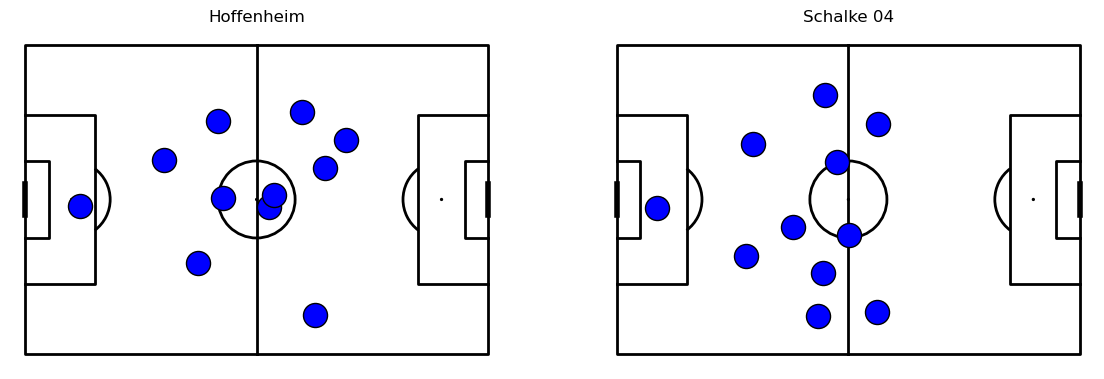

In [14]:
# 1. One match (both teams)
plot_network(passes, sb, match_id=3890561)

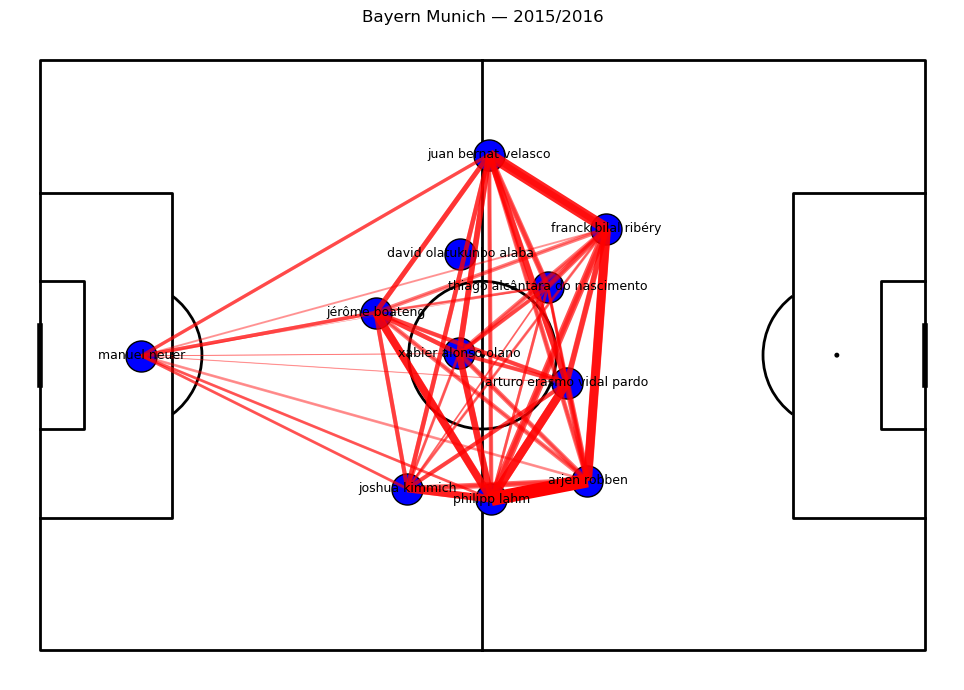

In [15]:
# 2. Team season (aggregated)
plot_network(passes, sb, team="Bayern Munich", season="2015/2016")

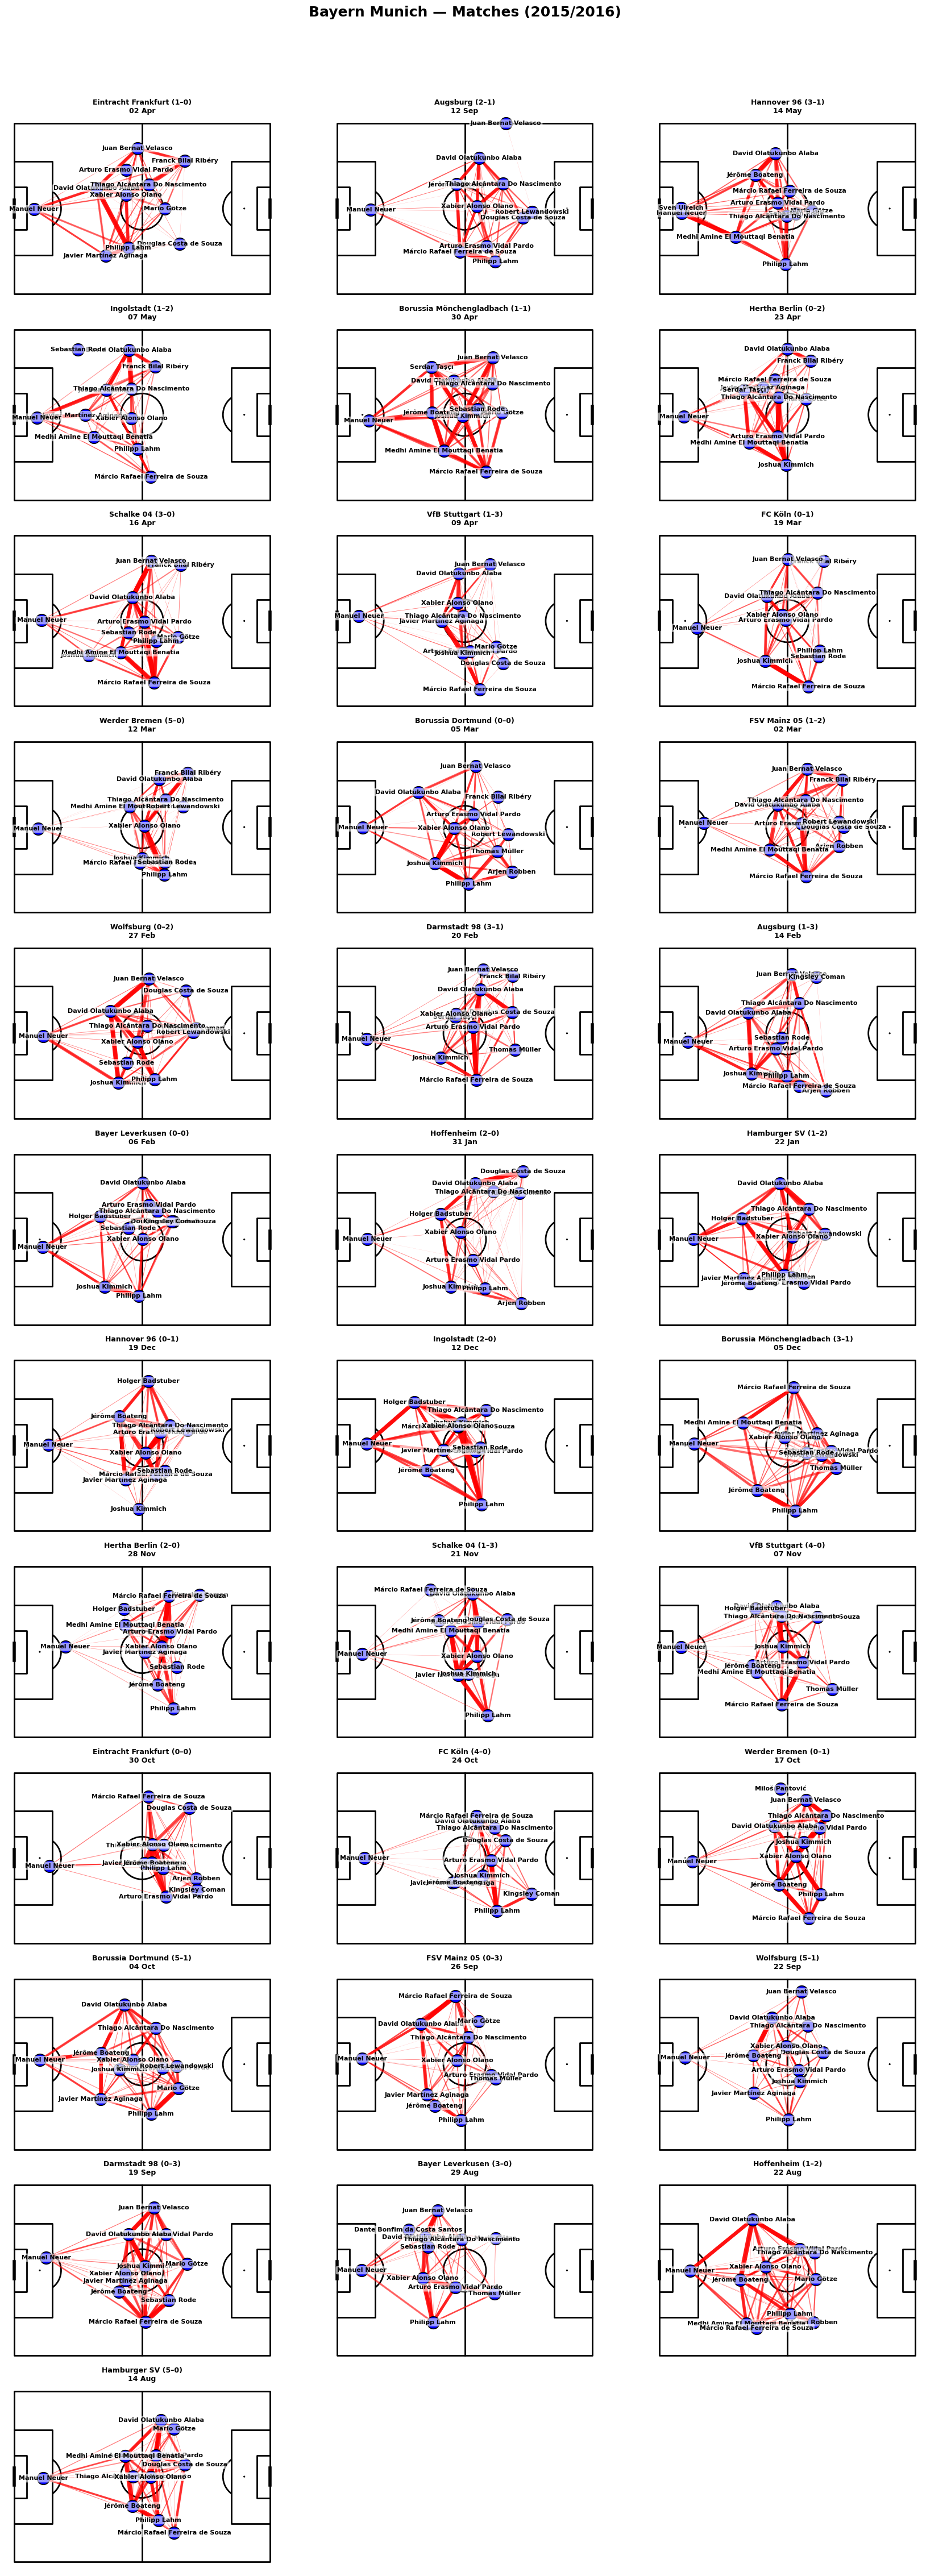

In [16]:
# 3. ALL matches for team → grid
plot_network(
    passes, sb,
    team="Bayern Munich",
    season="2015/2016",
    match_level=True,
    n_cols=3
)

In [ ]:
plot_network(
    passes,
    sb,
    season="2015/2016",
    n_cols=3   # this triggers the grid
)